In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the CSV
path = "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Study4.0Pilot/intuitive_feature_pilot.csv"
df = pd.read_csv(path)

# Select columns starting with p, r, or f 
cols_prf = df.filter(regex=r'^[prf]')



pspot_1
pthick_1
pcolor_1
pdirection_1
ptail_1
pclaw_1


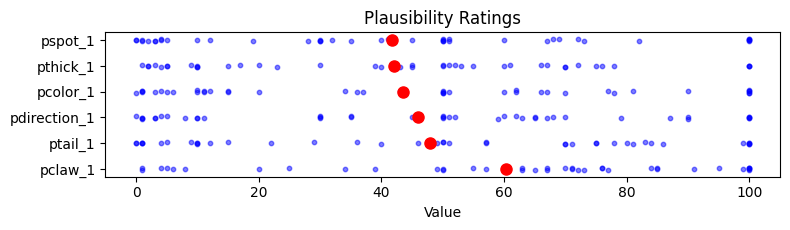

In [ ]:

# Select p* columns
p_cols = [c for c in df.columns if c.startswith("p")]

# Remove question-text rows
df_data = df.iloc[2:]

# Convert to numeric
df_p = df_data[p_cols].apply(pd.to_numeric, errors="coerce")

# Sort columns by mean for ordering purposes
summary_order = df_p.mean().sort_values(ascending=True).index

# Calculate column means
col_means = df_p[summary_order].mean()

fig, ax = plt.subplots(figsize=(8, len(summary_order) * 0.4))

y = np.arange(len(summary_order))

# Plot individual points
for i, col in enumerate(summary_order):
    jitter = (np.random.rand(len(df_p)) - 0.5) * 0.1  # small y jitter
    ax.scatter(df_p[col], i + jitter, color='blue', alpha=0.5, s=10)

# Overlay the mean as a red dot
ax.plot(col_means.values, y, 'o', color='red', markersize=8, label='Mean')

ax.set_yticks(y)
ax.set_yticklabels(summary_order)
ax.set_xlabel("Value")
ax.set_title("Plausibility Ratings")
ax.invert_yaxis()  # lowest mean at the top

plt.tight_layout()
plt.show()

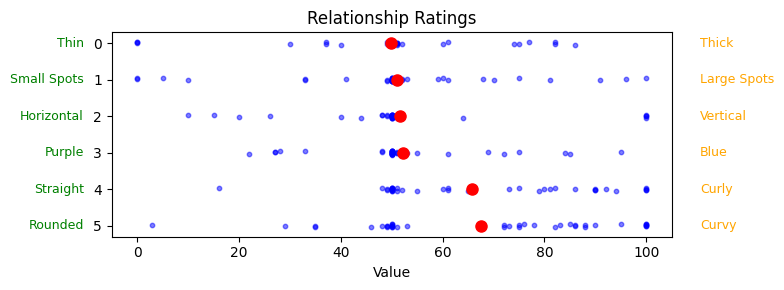

In [11]:

# Select r* columns
r_cols = [c for c in df.columns if c.startswith("r")]

# Remove question-text rows
df_data = df.iloc[2:]

# Convert to numeric
df_r = df_data[r_cols].apply(pd.to_numeric, errors="coerce")

# Sort columns by mean for y-axis ordering
summary_order = df_r.mean().sort_values(ascending=True).index

# Calculate column means
col_means = df_r[summary_order].mean()

# Create plot
fig, ax = plt.subplots(figsize=(8, len(summary_order) * 0.5))

y = np.arange(len(summary_order))

# Plot individual points
for i, col in enumerate(summary_order):
    jitter = (np.random.rand(len(df_r)) - 0.5) * 0.1
    ax.scatter(df_r[col], i + jitter, color='blue', alpha=0.5, s=10)

# Overlay means
ax.plot(col_means.values, y, 'o', color='red', markersize=8, label='Mean')

ax.set_xlabel("Value")
ax.set_title("Relationship Ratings")
ax.invert_yaxis()

# Map of directional values (must match summary order)
label_map = {
    "rspot_1": ("Small Spots", "Large Spots"),
    "rdirection_1": ("Horizontal", "Vertical"),
    "rcolor_1": ("Purple", "Blue"),
    "rclaw_1": ("Rounded", "Curvy"),
    "rtail_1": ("Straight", "Curly"),
    "rthick_1": ("Thin", "Thick"),
}


# Get axis limits to place labels
xmin, xmax = ax.get_xlim()
offset = 0.05 * (xmax - xmin)

# Add endpoint labels aligned to sorted order
for i, col in enumerate(summary_order):
    low_label, high_label = label_map[col]

    ax.text(xmin - offset, i, low_label,
            va='center', ha='right', color='green', fontsize=9)

    ax.text(xmax + offset, i, high_label,
            va='center', ha='left', color='orange', fontsize=9)

plt.tight_layout()
plt.show()

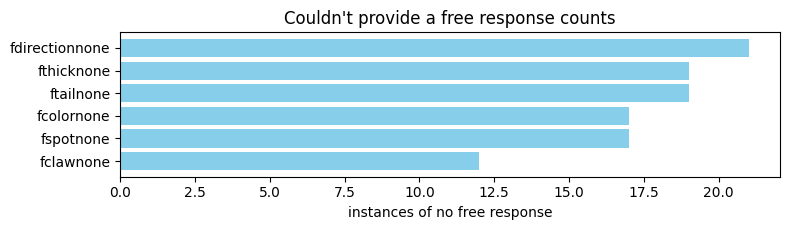

In [12]:
f_cols = [c for c in df.columns if c.startswith("f") and 'none' in c.lower()]

# Skip first two rows (question text)
df_data = df.iloc[2:]

# Convert all to string to handle mixed types
df_f = df_data[f_cols].astype(str)

# Count occurrences of 'none' per column - 'I can't think of any' (case-insensitive)
none_counts = (
    df_data[f_cols]
    .astype(str)
    .apply(lambda col: col.str.strip().str.lower() == "i can't think of any")
    .sum()
    .sort_values(ascending=True)
)

# Sort by count ascending
none_counts = none_counts.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, len(f_cols) * 0.4))

y = range(len(none_counts))
ax.barh(y, none_counts.values, color="skyblue")
ax.set_yticks(y)
ax.set_yticklabels(none_counts.index)
ax.set_xlabel("instances of no free response")
ax.set_title("Couldn't provide a free response counts")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Select all f* columns that are **free responses**, ignoring 'none' checkboxes
f_cols = [c for c in df.columns if c.startswith("f")]

# Skip the first two rows (question text)
df_data = df.iloc[2:]

# Convert to string 
df_f = df_data[f_cols].astype(str)

# Print free responses per column (ignore 'none' or empty strings)
for col in f_cols:
    # Keep only non-empty, non-'none' entries
    free_responses = df_f[col][~df_f[col].str.lower().isin(['none', '', 'nan'])]
    
    print(f"\nColumn: {col} (total {len(free_responses)})")
    for i, resp in enumerate(free_responses, start=1):
        print(f"{i}. {resp}")


Column: fspot (total 20)
1. it could be a camoflauge issue
2. Depending on the environment, one or the other might have better camouflage.
3. Bigger spots mean more food.
4. That the reptile still has more growing to do and what appears to be large spots will become smaller as it reaches adulthood.
5. Sunlight absorption and what nutritional needs have to come from the food.  Less spots would equal more absorption meaning more energy from the sun. 
6. The small spots make the reptile less conspicuous. It allows the reptile to stand out less so that it can more easily capture some food.
7. A certain pattern might offer better camouflage, which might allow the reptile to survive better and therefore acquire/eat more food since it can't eat if it's dead. 
8. possible for better camouflage 
9. I'm thinking that the larger spots might require more of a certain protein or amino acid to manifest these big spots but - ??
10. The small spots would blend into the sand better than the large spot